load dataset

In [40]:
import os
import cv2

image_dir = "../data/raw/images"

images = {}
for file in os.listdir(image_dir):
    if file.endswith(".jpg"):
        path = os.path.join(image_dir, file)
        img = cv2.imread(path)
        if img is not None:
            images[file] = img

len(images)

786

add matching function

In [41]:
def match_keypoints(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    return len(matches)

run similarity search

In [42]:
query_name = list(images.keys())[0]
query_img = images[query_name]

scores = []

for name, img in images.items():
    if name == query_name:
        continue

    score = match_keypoints(query_img, img)
    scores.append((name, score))

# sort descending
scores = sorted(scores, key=lambda x: x[1], reverse=True)

scores[:5]

[('eFOZj6S7m8g.jpg', 182),
 ('bvstPAJwAt8.jpg', 181),
 ('nyLrdKs0uNw.jpg', 178),
 ('tgE9orZtrek.jpg', 176),
 ('-_QNbl0PrcE.jpg', 176)]

visualize top matches

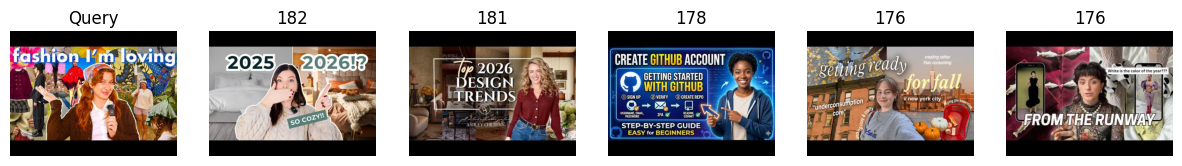

In [43]:
import matplotlib.pyplot as plt

top_k = 5

fig, ax = plt.subplots(1, top_k+1, figsize=(15,5))

# show query
ax[0].imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Query")
ax[0].axis("off")

for i, (name, score) in enumerate(scores[:top_k]):
    img = images[name]
    ax[i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[i+1].set_title(f"{score}")
    ax[i+1].axis("off")

plt.show()

attempt to improve the matching

In [44]:
def preprocess(img):
    return cv2.resize(img, (320, 180))


def match_keypoints(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    img1 = preprocess(img1)
    img2 = preprocess(img2)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return len(good)

In [45]:
query_name = list(images.keys())[0]
query_img = images[query_name]

scores = []

for name, img in images.items():
    if name == query_name:
        continue

    score = match_keypoints(query_img, img)
    scores.append((name, score))

# sort best → worst
scores = sorted(scores, key=lambda x: x[1], reverse=True)

scores[:5]

[('-veNidDqCpo.jpg', 9),
 ('BHmyxsIdOHQ.jpg', 9),
 ('owaGhMwNHc4.jpg', 8),
 ('xcOVNQ8A0jw.jpg', 8),
 ('LVrbc0woPEc.jpg', 7)]

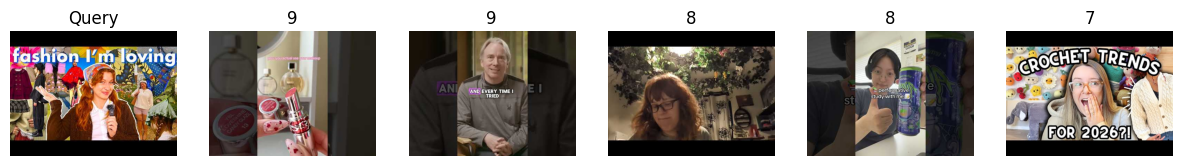

In [46]:
import matplotlib.pyplot as plt

top_k = 5

fig, ax = plt.subplots(1, top_k + 1, figsize=(15,5))

# Query image
ax[0].imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
ax[0].set_title("Query")
ax[0].axis("off")

# Top matches
for i, (name, score) in enumerate(scores[:top_k]):
    img = images[name]

    ax[i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[i+1].set_title(f"{score}")
    ax[i+1].axis("off")

plt.show()

show matched keypoints

In [47]:
def draw_matches(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    img1_p = preprocess(img1)
    img2_p = preprocess(img2)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1_p, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2_p, cv2.COLOR_BGR2GRAY), None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    img_matches = cv2.drawMatches(
        img1_p, kp1,
        img2_p, kp2,
        good[:30],  # limit for clarity
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return img_matches

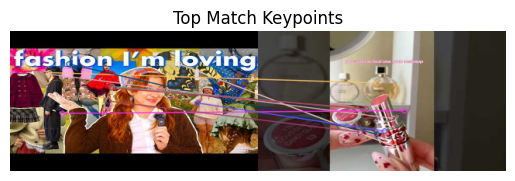

In [48]:
match_vis = draw_matches(query_img, images[scores[0][0]])

plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
plt.title("Top Match Keypoints")
plt.axis("off")
plt.show()

In [49]:
def draw_matches(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    img1_p = preprocess(img1)
    img2_p = preprocess(img2)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1_p, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2_p, cv2.COLOR_BGR2GRAY), None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    # sort by distance
    good = sorted(good, key=lambda x: x.distance)

    img_matches = cv2.drawMatches(
        img1_p, kp1,
        img2_p, kp2,
        good[:10],  # only top 10 strongest matches
        None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    return img_matches

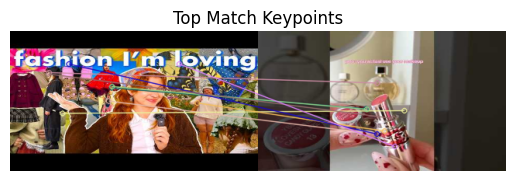

In [50]:
img_matches = draw_matches(query_img, images[scores[0][0]])

import matplotlib.pyplot as plt
import cv2

plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title("Top Match Keypoints")
plt.axis("off")
plt.show()

## improve by adding edge, color, etc. 

In [51]:
import cv2
import numpy as np

def preprocess(img):
    return cv2.resize(img, (320, 180))


# -----------------------------
# ORB-only similarity
# -----------------------------
def match_keypoints(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    img1 = preprocess(img1)
    img2 = preprocess(img2)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 30 and m.distance < 0.6 * n.distance:
            good.append(m)

    return len(good)


# -----------------------------
# Edge similarity
# -----------------------------
def edge_similarity(img1, img2):
    e1 = cv2.Canny(preprocess(img1), 100, 200)
    e2 = cv2.Canny(preprocess(img2), 100, 200)

    return np.sum(e1 == e2) / e1.size


# -----------------------------
# Color similarity
# -----------------------------
def color_similarity(img1, img2):
    img1 = preprocess(img1)
    img2 = preprocess(img2)

    hist1 = cv2.calcHist([img1], [0,1,2], None, [8,8,8], [0,256]*3)
    hist2 = cv2.calcHist([img2], [0,1,2], None, [8,8,8], [0,256]*3)

    hist1 = cv2.normalize(hist1, hist1).flatten()
    hist2 = cv2.normalize(hist2, hist2).flatten()

    return cv2.compareHist(hist1, hist2, cv2.HISTCMP_CORREL)


# -----------------------------
# Hybrid similarity
# -----------------------------
def combined_similarity(img1, img2):
    kp = match_keypoints(img1, img2)
    edge = edge_similarity(img1, img2)
    color = color_similarity(img1, img2)

    return (0.5 * kp) + (0.25 * edge) + (0.25 * color)

In [52]:
query_name = list(images.keys())[20]
query_img = images[query_name]

orb_scores = []
hybrid_scores = []

for name, img in images.items():
    if name == query_name:
        continue

    orb = match_keypoints(query_img, img)
    hybrid = combined_similarity(query_img, img)

    orb_scores.append((name, orb))
    hybrid_scores.append((name, hybrid))


# sort
orb_scores = sorted(orb_scores, key=lambda x: x[1], reverse=True)
hybrid_scores = sorted(hybrid_scores, key=lambda x: x[1], reverse=True)

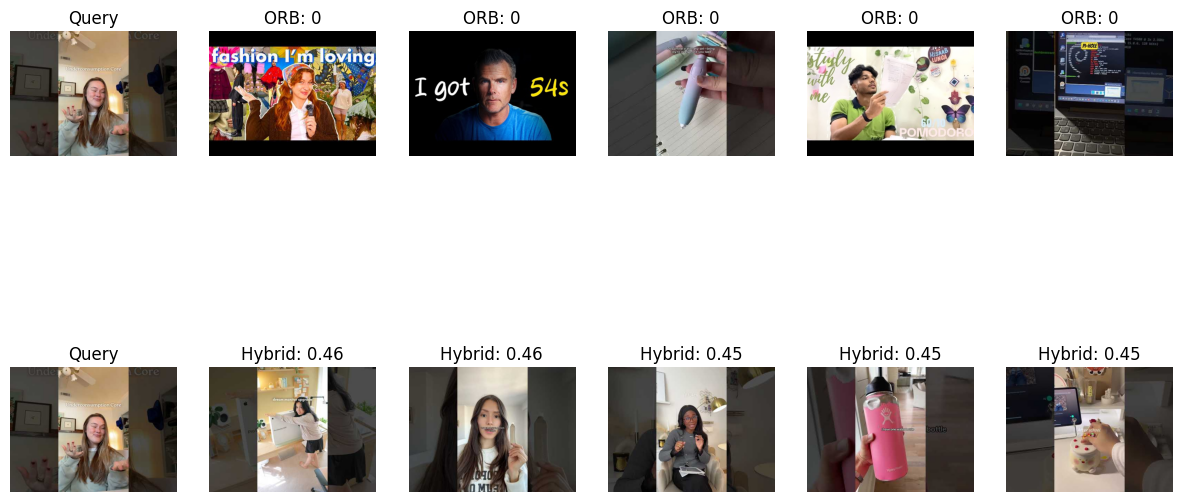

In [53]:
import matplotlib.pyplot as plt

top_k = 5

fig, ax = plt.subplots(2, top_k + 1, figsize=(15,8))

# Query
ax[0,0].imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
ax[0,0].set_title("Query")
ax[0,0].axis("off")

ax[1,0].imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
ax[1,0].set_title("Query")
ax[1,0].axis("off")



# ORB row
for i, (name, score) in enumerate(orb_scores[:top_k]):
    img = images[name]
    ax[0,i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[0,i+1].set_title(f"ORB: {score}")
    ax[0,i+1].axis("off")


# Hybrid row
for i, (name, score) in enumerate(hybrid_scores[:top_k]):
    img = images[name]
    ax[1,i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[1,i+1].set_title(f"Hybrid: {score:.2f}")
    ax[1,i+1].axis("off")


plt.show()

## Try to compare against SIFT

In [54]:
def orb_similarity(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    img1 = preprocess(img1)
    img2 = preprocess(img2)

    kp1, des1 = orb.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = orb.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 30 and m.distance < 0.6 * n.distance:
            good.append(m)

    return len(good)

In [55]:
def sift_similarity(img1, img2):
    sift = cv2.SIFT_create()

    img1 = preprocess(img1)
    img2 = preprocess(img2)

    kp1, des1 = sift.detectAndCompute(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), None)
    kp2, des2 = sift.detectAndCompute(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), None)

    if des1 is None or des2 is None:
        return 0

    bf = cv2.BFMatcher(cv2.NORM_L2)
    matches = bf.knnMatch(des1, des2, k=2)

    good = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append(m)

    return len(good)


def sift_hybrid(img1, img2):
    return (
        0.4 * sift_similarity(img1, img2) +
        0.3 * edge_similarity(img1, img2) +
        0.3 * color_similarity(img1, img2)
    )

def orb_hybrid(img1, img2):
    return (
        0.4 * orb_similarity(img1, img2) +
        0.3 * edge_similarity(img1, img2) +
        0.3 * color_similarity(img1, img2)
    )


In [56]:
orb_scores = []
orb_hybrid_scores = []
sift_hybrid_scores = []

for name, img in images.items():
    if name == query_name:
        continue

    orb_scores.append((name, orb_similarity(query_img, img)))
    orb_hybrid_scores.append((name, orb_hybrid(query_img, img)))
    sift_hybrid_scores.append((name, sift_hybrid(query_img, img)))

# sort
orb_scores = sorted(orb_scores, key=lambda x: x[1], reverse=True)
orb_hybrid_scores = sorted(orb_hybrid_scores, key=lambda x: x[1], reverse=True)
sift_hybrid_scores = sorted(sift_hybrid_scores, key=lambda x: x[1], reverse=True)

## visualize alll 3 methods

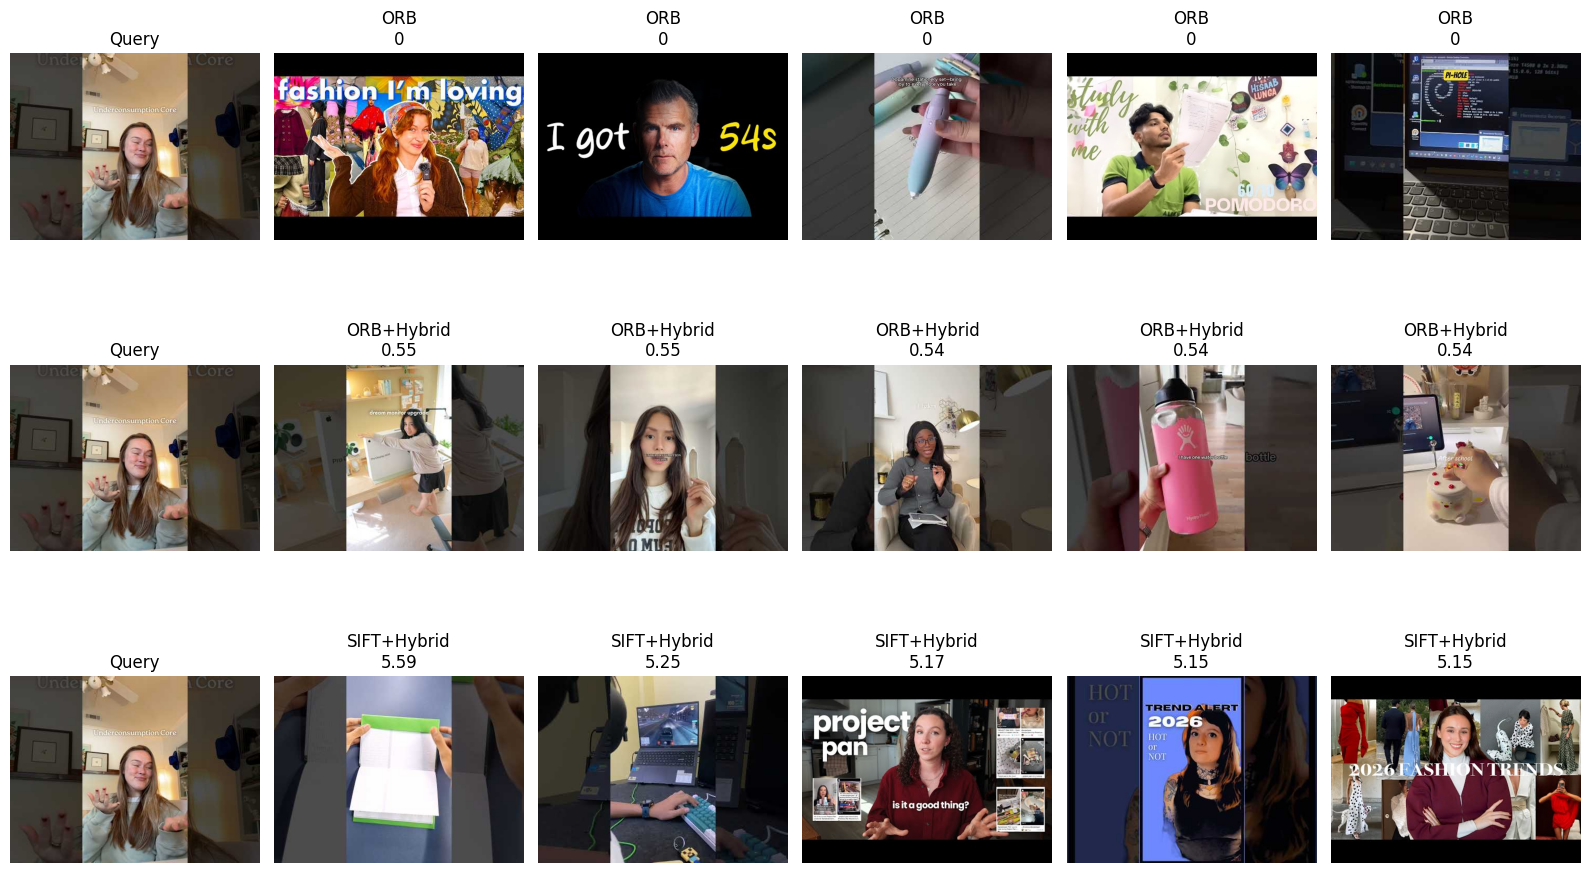

In [57]:
import matplotlib.pyplot as plt
import cv2

top_k = 5

fig, ax = plt.subplots(3, top_k + 1, figsize=(16,10))

# -----------------------------
# Column 0: Query Image (all rows)
# -----------------------------
for row in range(3):
    ax[row, 0].imshow(cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB))
    ax[row, 0].set_title("Query")
    ax[row, 0].axis("off")


# -----------------------------
# Row 1: ORB
# -----------------------------
for i, (name, score) in enumerate(orb_scores[:top_k]):
    img = images[name]
    ax[0, i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[0, i+1].set_title(f"ORB\n{score}")
    ax[0, i+1].axis("off")


# -----------------------------
# Row 2: ORB Hybrid
# -----------------------------
for i, (name, score) in enumerate(orb_hybrid_scores[:top_k]):
    img = images[name]
    ax[1, i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[1, i+1].set_title(f"ORB+Hybrid\n{score:.2f}")
    ax[1, i+1].axis("off")


# -----------------------------
# Row 3: SIFT Hybrid
# -----------------------------
for i, (name, score) in enumerate(sift_hybrid_scores[:top_k]):
    img = images[name]
    ax[2, i+1].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax[2, i+1].set_title(f"SIFT+Hybrid\n{score:.2f}")
    ax[2, i+1].axis("off")


plt.tight_layout()
plt.show()